<a href="https://colab.research.google.com/github/ArthurCBx/Applied_MachineLearning_in_Python/blob/main/Module4/Supervised_ML_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setting datasets

In [ ]:
!git clone https://github.com/ArthurCBx/Applied_MachineLearning_in_Python.git

Cloning into 'Applied_MachineLearning_in_Python'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 62 (delta 9), reused 29 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 12.44 MiB | 15.90 MiB/s, done.
Resolving deltas: 100% (9/9), done.


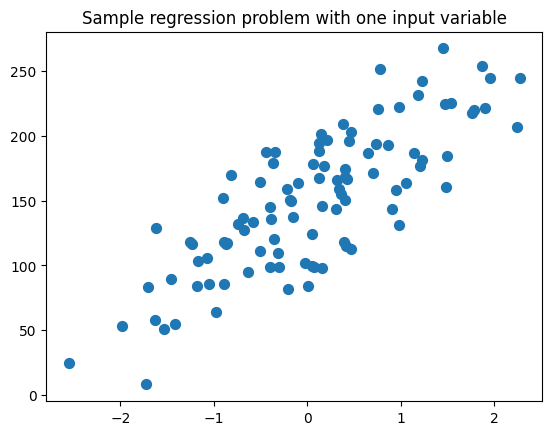

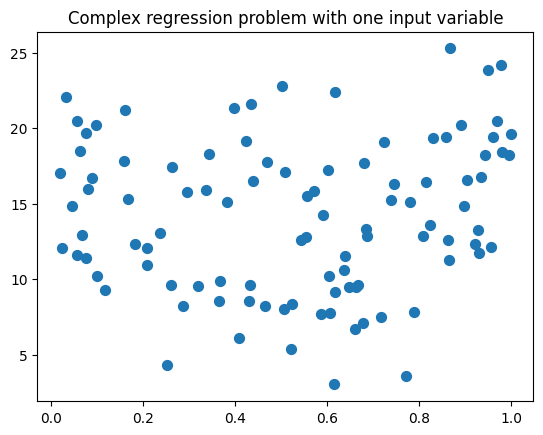

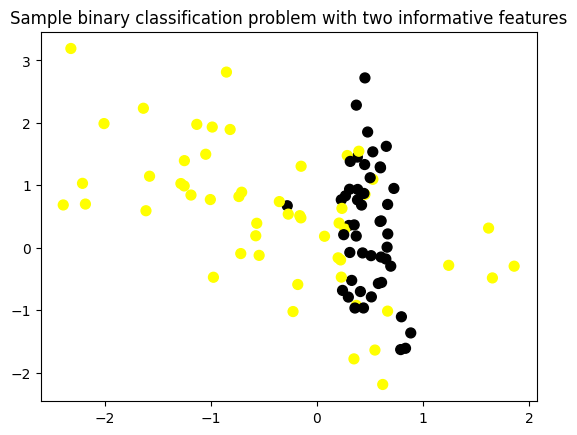

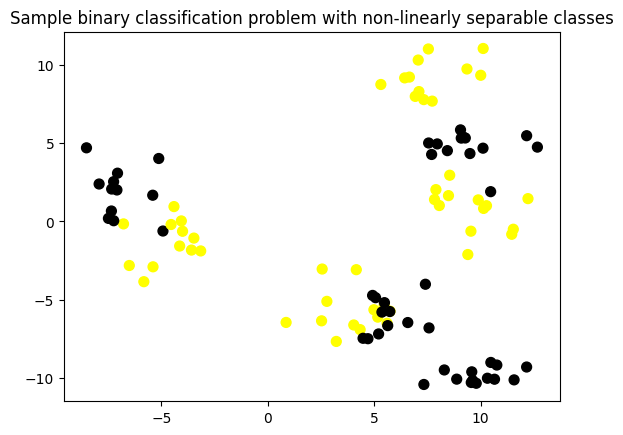

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_blobs
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_breast_cancer
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import load_crime_dataset


cmap_bold = ListedColormap(['#FFFF00', '#00FF00', '#0000FF','#000000'])

# fruits dataset
fruits = pd.read_table('/content/Applied_MachineLearning_in_Python/Module1/data/fruit_data_with_colors.txt')

feature_names_fruits = ['height', 'width', 'mass', 'color_score']
X_fruits = fruits[feature_names_fruits]
y_fruits = fruits['fruit_label']
target_names_fruits = ['apple', 'mandarin', 'orange', 'lemon']

X_fruits_2d = fruits[['height', 'width']]
y_fruits_2d = fruits['fruit_label']

# synthetic dataset for simple regression
from sklearn.datasets import make_regression
plt.figure()
plt.title('Sample regression problem with one input variable')
X_R1, y_R1 = make_regression(n_samples = 100, n_features=1,
                            n_informative=1, bias = 150.0,
                            noise = 30, random_state=0)
plt.scatter(X_R1, y_R1, marker= 'o', s=50)
plt.show()

# synthetic dataset for more complex regression
from sklearn.datasets import make_friedman1
plt.figure()
plt.title('Complex regression problem with one input variable')
X_F1, y_F1 = make_friedman1(n_samples = 100, n_features = 7,
                           random_state=0)

plt.scatter(X_F1[:, 2], y_F1, marker= 'o', s=50)
plt.show()

# synthetic dataset for classification (binary)
plt.figure()
plt.title('Sample binary classification problem with two informative features')
X_C2, y_C2 = make_classification(n_samples = 100, n_features=2,
                                n_redundant=0, n_informative=2,
                                n_clusters_per_class=1, flip_y = 0.1,
                                class_sep = 0.5, random_state=0)
plt.scatter(X_C2[:, 0], X_C2[:, 1], marker= 'o',
           c=y_C2, s=50, cmap=cmap_bold)
plt.show()

# more difficult synthetic dataset for classification (binary)
# with classes that are not linearly separable
X_D2, y_D2 = make_blobs(n_samples = 100, n_features = 2,
                       centers = 8, cluster_std = 1.3,
                       random_state = 4)
y_D2 = y_D2 % 2
plt.figure()
plt.title('Sample binary classification problem with non-linearly separable classes')
plt.scatter(X_D2[:,0], X_D2[:,1], c=y_D2,
           marker= 'o', s=50, cmap=cmap_bold)
plt.show()

# Breast cancer dataset for classification
cancer = load_breast_cancer()
(X_cancer, y_cancer) = load_breast_cancer(return_X_y = True)

# Communities and Crime dataset
(X_crime, y_crime) = load_crime_dataset()

# Naive Bayes Classifier
## Simple and probabilistic classifier family
- These classifiers are called 'Naive' because they assume that features are conditionally independent, given the class;
- In other words: they assume that, for all instances of a given class, the features have little/no correlation with each other;
- Highly efficient learning and prediction;
- But generalization performance may be worse than more sophisticated learning models;
- Can be competitive for some tasks.

## Naive Bayes Classifier Types
- Bernoulli: binary features (e.g. word presence/absence);
- Multinomial: discrete features (e.g. word counts);
- Gaussian: continuous/real-valued features.
  - Statistics computed for each class: mean and standard deviation for each feature.

### Gaussian example

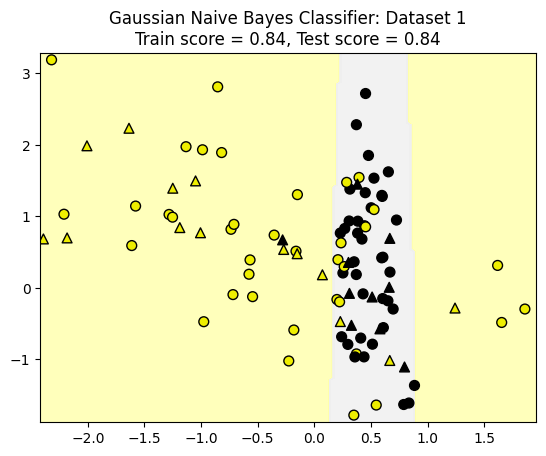

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_class_regions_for_classifier

X_train, X_test, y_train, y_test = train_test_split(X_C2, y_C2, random_state=0)

nbclf = GaussianNB().fit(X_train, y_train)
plot_class_regions_for_classifier(nbclf, X_train, y_train, X_test, y_test,
                                  'Gaussian Naive Bayes Classifier: Dataset 1')

### Application to a real-world dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, random_state=0)
nbclf = GaussianNB().fit(X_train, y_train)
print('Breast cancer dataset')
print(f'Accuracy of GaussianNB classifier on training set {nbclf.score(X_train, y_train):.2f}')
print(f'Accuracy of GaussianNB classifier on test set {nbclf.score(X_test, y_test):.2f}')

Breast cancer dataset
Accuracy of GaussianNB classifier on training set 0.95
Accuracy of GaussianNB classifier on test set 0.94


## Naive Bayes classifiers: Pros and Cons
### Pros:
- Easy to understand;
- Simple, efficient parameter estimation;
- Works well with high-dimensional data;
- Often useful as a baseline comparison to more sophisticated methods;

### Cons
- Assumption that features are conditionally independent given the class is not realistic;
- As a result, other classifier types often have better generalization performance;
- Their confidence estimates for predictions are not very accurate.

# Random Forests
- An ensemble of trees, not just one tree;
- Widely used, very good results on many problems;
- `sklearn.ensemble` module:
  - Classification: RandomForestClassifier;
  - Regression: RandomForesRegressor.
- One decision tree -> Prone to overfitting;
- Many decision trees -> More stable, better generalization;
- Ensemble of trees should be diverse: introduce random variation into tree-building. This can be:
  - Randomized bootstrap copies (n_estimator parameter);
  - Randomized feature splits

## Random Forest max_features Parameter
- Learning is quite sensitive to this parameter;
- Setting max_features = 1 leads to forests with deives, more complex trees;
- Setting max_features = [close to number of features] will lead to similar forests with simpler trees.



## Prediction Using Random Forests
1. Make a prediction for every tree in the forest.
2. Combine individual predictions
    - Regression: mean of individual tree predictions;
    - Classification:
      - Each tree gives probability for each class;
      - Probabilities averaged across trees;
      - Predict the class with highest probability.

### Random forest: Fruit dataset

Random Forest, Fruit dataset, default settings
Accuracy of RF classifier on training set: 1.00
Accuracy of RF classifier on test set: 0.8


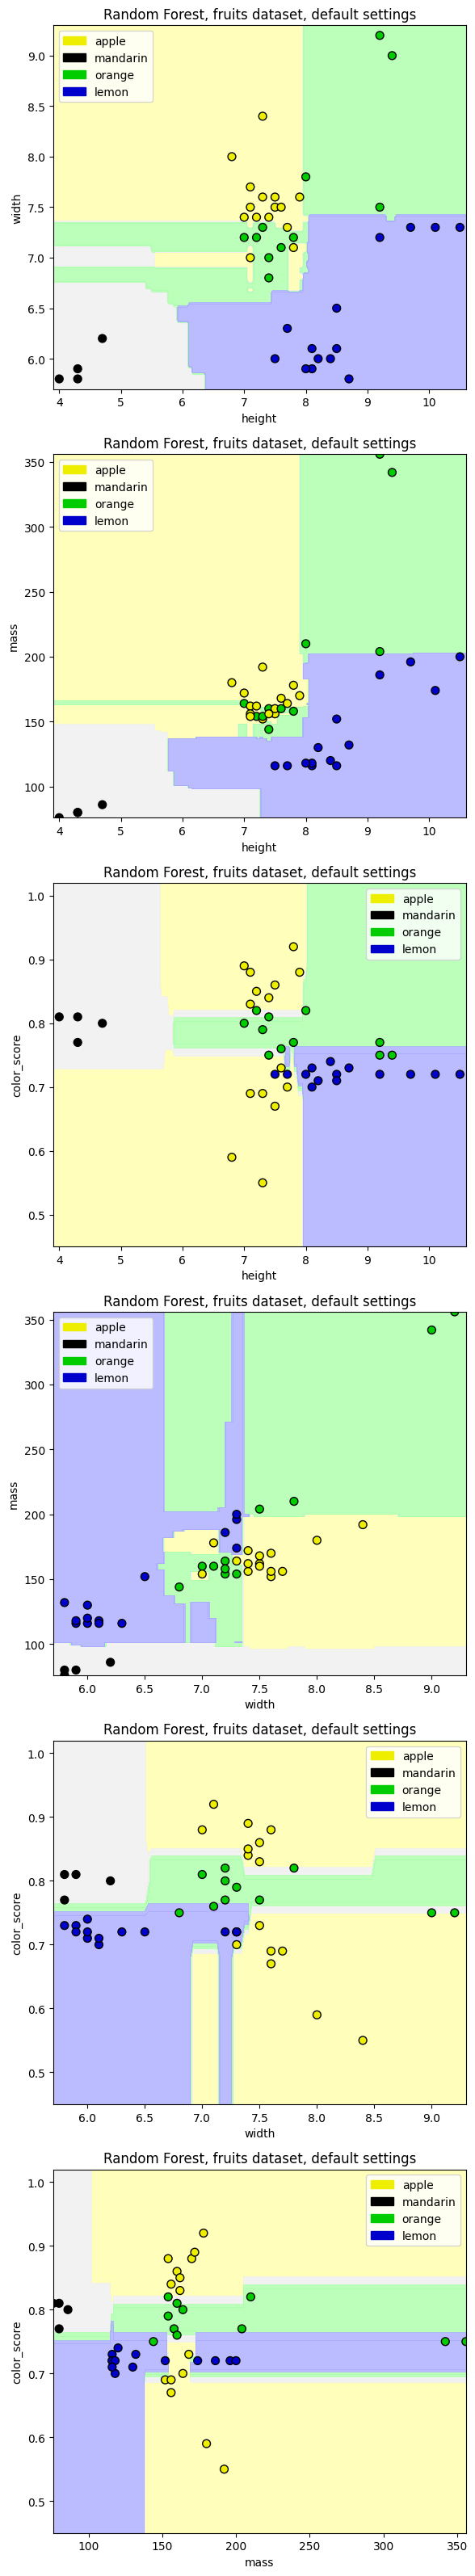

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_class_regions_for_classifier_subplot

X_train, X_test, y_train, y_test = train_test_split(X_fruits.to_numpy(),
                                                    y_fruits.to_numpy(), random_state=0)

fig, subaxes = plt.subplots(6, 1, figsize=(6, 32))
title = 'Random Forest, fruits dataset, default settings'
pair_list = [[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]

for pair, axis in zip(pair_list, subaxes):
  X = X_train[:, pair]
  y = y_train

  clf = RandomForestClassifier().fit(X, y)
  plot_class_regions_for_classifier_subplot(clf, X, y, None,
                                            None, title, axis,
                                            target_names_fruits)

  axis.set_xlabel(feature_names_fruits[pair[0]])
  axis.set_ylabel(feature_names_fruits[pair[1]])

plt.tight_layout()
clf = RandomForestClassifier(n_estimators = 10,
                            random_state=0).fit(X_train, y_train)

print('Random Forest, Fruit dataset, default settings')
print(f'Accuracy of RF classifier on training set: {clf.score(X_train, y_train):.2f}')
print(f'Accuracy of RF classifier on test set: {clf.score(X_test, y_test)}')

### Random Forests on a real-world dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, random_state = 0)

clf = RandomForestClassifier(max_features=8, random_state=0)
clf.fit(X_train, y_train)

print('Breast cancer dataset')
print(f'Accuracy of RF classifier on training set: {clf.score(X_train, y_train):.2f}')
print(f'Accuracy of RF classifier on test set: {clf.score(X_test, y_test):.2f}')

Breast cancer dataset
Accuracy of RF classifier on training set: 1.00
Accuracy of RF classifier on test set: 0.97


## Random Forest: Pros and Cons
### Pros:
- Widely used, excellent prediction performance on many problems;
- Doesn't require careful normalization of features or extensive parameter tuning;
- Like decision trees, handles a mixture of feature types;
- Easily parallelized across multiple CPUs.

### Cons:
- The resulting models are often difficult for humans to interpret;
- Like decision trees, random forests may not be a good choice for very high-dimensional tasks (e.g. text classifiers) compared to fast accurate linear models.

## Random Forests: RandomForestClassifier Key Parameters
1. n_estimators: number of trees to use in ensemble - Should be larger for larger datasets to reduce overfitting;
2. max_features: has a strong effect on performance. Influences diversity of trees in the fores;
3. max_depth: controls the depth of each tree (default: None. Splits until all leaves are pure);
4. n_jobs: How many cores to use in parallel during trainig;


# Gradient Boosted Decision Trees

- Training builds a series of small decision trees;
- Each tree attempts to correct errors from the previous stage;
- The learning rate controls how hard each new tree tries to correct remaining mistakes from previous round:
  - High learning rate: more complex trees;
  - Low learning rate: simpler trees.

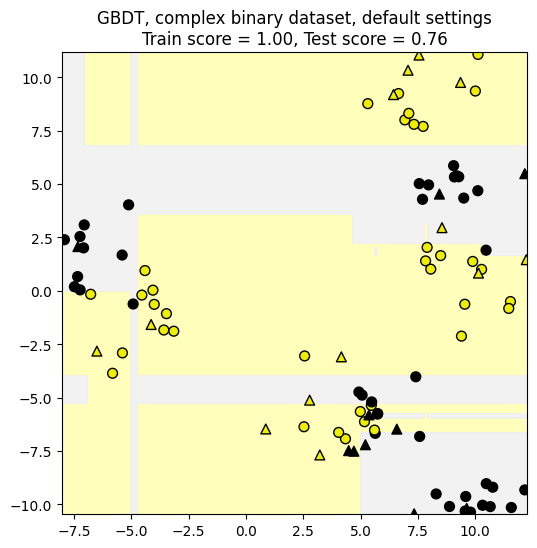

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(X_D2, y_D2,
                                                    random_state=0)

fig, subaxes = plt.subplots(1, 1, figsize=(6, 6))
clf = GradientBoostingClassifier().fit(X_train, y_train)
title = 'GBDT, complex binary dataset, default settings'
plot_class_regions_for_classifier_subplot(clf, X_train, y_train, X_test,
                                          y_test, title, subaxes)

### Gradient-boosted decision trees on a real-world dataset


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, random_state=0)

clf = GradientBoostingClassifier(random_state=0)
clf.fit(X_train, y_train)

print('Breast cancer dataset (learning_rate=0.1, max_depth=3)')
print(f'Accuracy of GBDT classifier on training set: {clf.score(X_train, y_train):.2f}')
print(f'Accuracy of GBDT classifier on test set: {clf.score(X_test, y_test):.2f}')

clf = GradientBoostingClassifier(learning_rate=0.01, max_depth=2 , random_state=0)
clf.fit(X_train, y_train)

print('Breast cancer dataset (learning_rate=0.01, max_depth=2)')
print(f'Accuracy of GBDT classifier on training set: {clf.score(X_train, y_train):.2f}')
print(f'Accuracy of GBDT classifier on test set: {clf.score(X_test, y_test):.2f}')

Breast cancer dataset (learning_rate=0.1, max_depth=3)
Accuracy of GBDT classifier on training set: 1.00
Accuracy of GBDT classifier on test set: 0.97
Breast cancer dataset (learning_rate=0.01, max_depth=2)
Accuracy of GBDT classifier on training set: 0.97
Accuracy of GBDT classifier on test set: 0.97


## GBDT: Pros and Cons
### Pros:
- Oftem best off-the-shelf accuracy on many problems;
- Using model for prediction requires only modest memory and is fast;
- Doesn't require careful normalization of features to perform well;
- Like decision trees, handles a mixture of feature types.

### Cons:
- Like random forests, the models are often difficult for humans to interpret;
- Requires careful tuning of the learning rate and other parameters;
- Training can require significant computation;
- Like decision trees, not recommended for text classification and other problems with very high dimensional sparse features, for accuracy and computation cost reasons.

## GDBT: GradientBoostingClassifier Key Parameters
1. n_estimators: sets number of small decision trees to use (weak learners) in the ensemble;
2. learning_rate: controls emphasis on fixing errors from previous iterations;
- The above two are typically tuned together
- n_estimators is adjusted first, to best exploit memory and CPUs during trainig, then other parameters;
- max_depth is typically set to a small value (e.g. 3-5) for most applications.

# Neural Network

## Multi-layer Perceptron with One Hidden Layer
output = activation_function(input_varible * coefficient_learned1) * coefficient_learned2

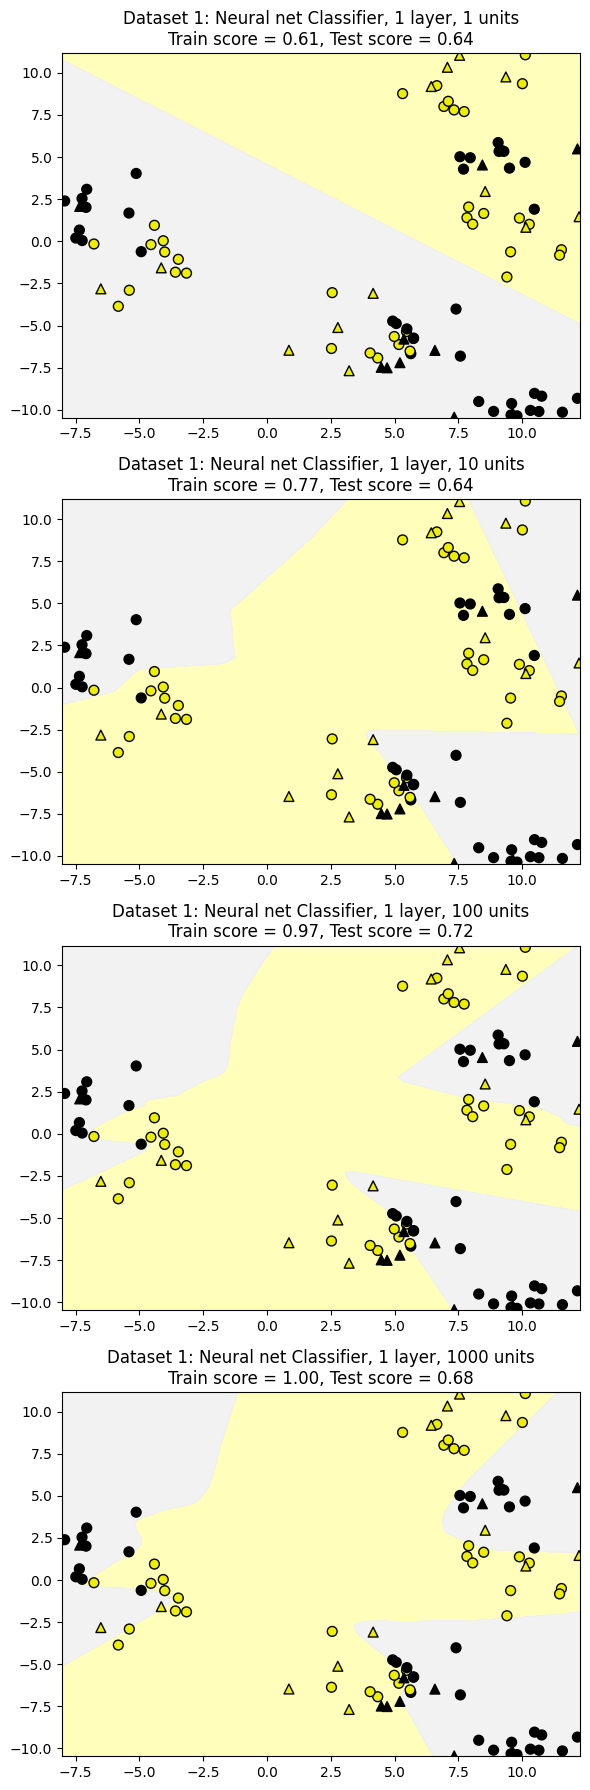

In [ ]:
from sklearn.neural_network import MLPClassifier

X_train, X_test, y_train, y_test = train_test_split(X_D2, y_D2, random_state=0)

fig, subaxes = plt.subplots(4, 1, figsize=(6, 18))

for units, axis in zip([1, 10, 100, 1000], subaxes):
  nnclf = MLPClassifier(hidden_layer_sizes = [units], solver='lbfgs', #solver is the algorithm to learn the parameters
                        random_state=0, max_iter=10000).fit(X_train, y_train)
  title = f'Dataset 1: Neural net Classifier, 1 layer, {units} units'
  plot_class_regions_for_classifier_subplot(nnclf, X_train, y_train,
                                            X_test, y_test, title, axis)
  plt.tight_layout()

### Synthetic dataset 1: 2 hidden layers

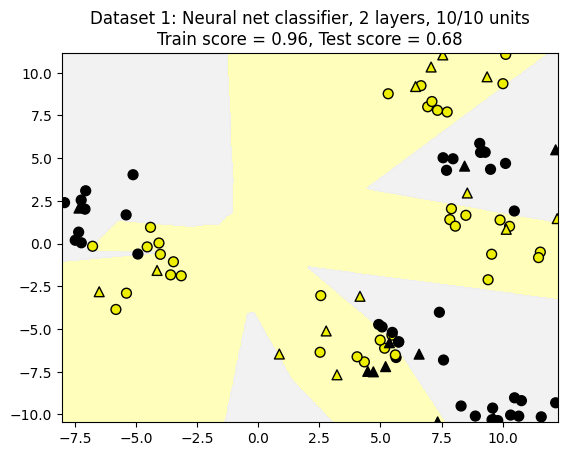

In [ ]:
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_class_regions_for_classifier

nnclf = MLPClassifier(hidden_layer_sizes=[10, 10], solver='lbfgs', max_iter=10000,
                      random_state=0).fit(X_train, y_train)

plot_class_regions_for_classifier(nnclf, X_train, y_train, X_test, y_test,
                                          'Dataset 1: Neural net classifier, 2 layers, 10/10 units')

### Regularization parameter: alpha
- Penalty for incorrect classifications during learning phase

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS R

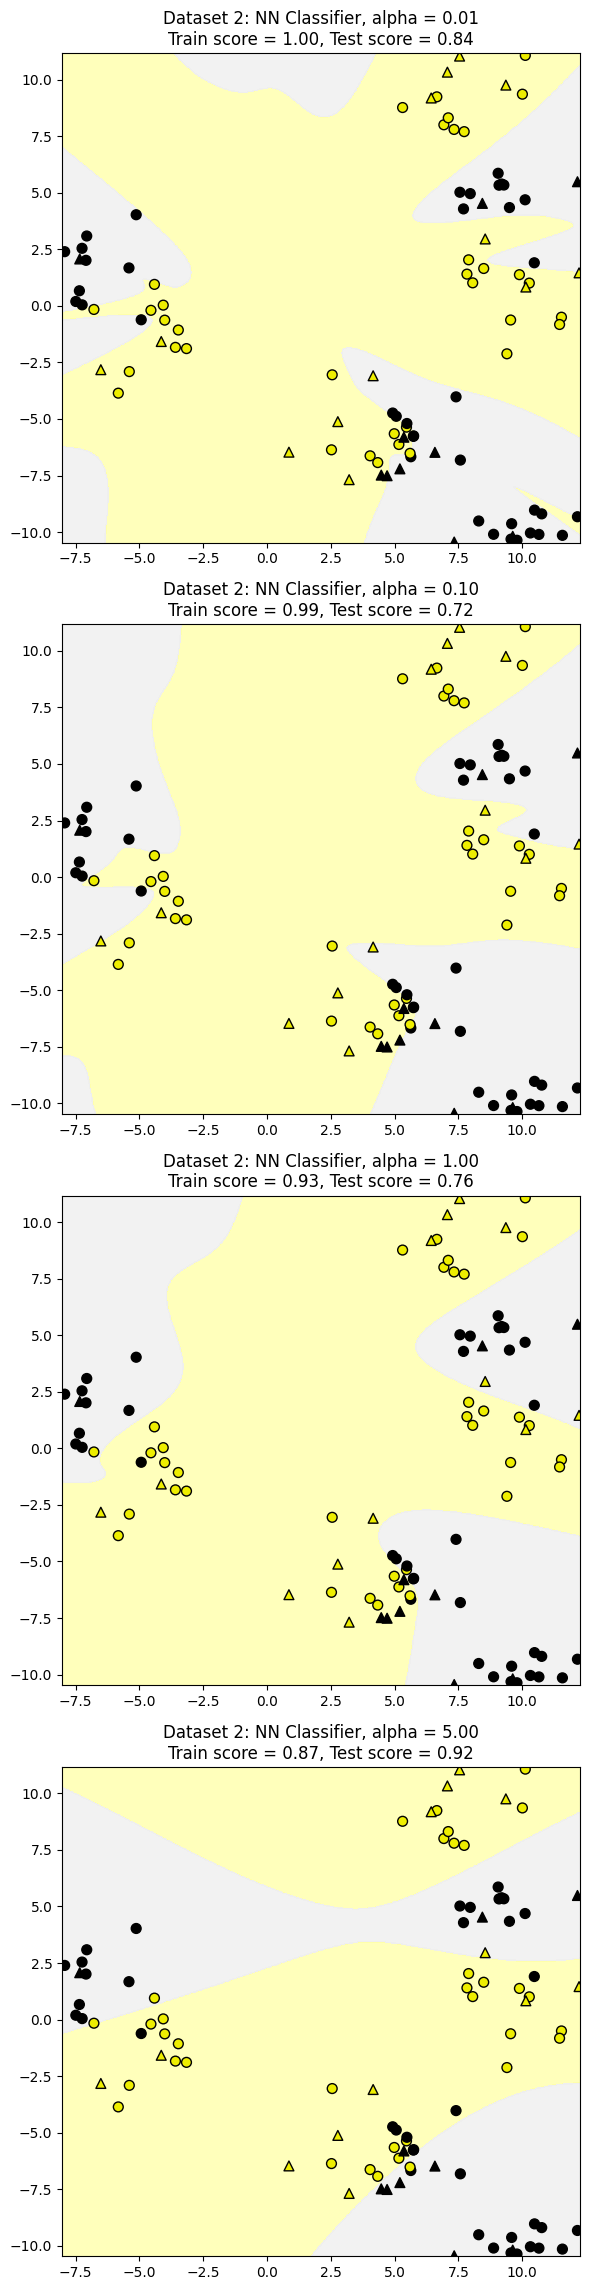

In [ ]:
fig, subaxes = plt.subplots(4, 1, figsize=(6, 23))

for this_alpha, axis in zip([0.01, 0.1, 1.0, 5.0], subaxes):
  nnclf = MLPClassifier(hidden_layer_sizes=[100, 100], solver='lbfgs',
                      max_iter=1000, activation='tanh', alpha=this_alpha,
                      random_state=0).fit(X_train, y_train)

  title = f'Dataset 2: NN Classifier, alpha = {this_alpha:.2f}'

  plot_class_regions_for_classifier_subplot(nnclf, X_train, y_train,
                                            X_test, y_test, title, axis)
  plt.tight_layout()

### Application to real_world dataset for classification

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer,
                                                    random_state=0)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

clf = MLPClassifier(hidden_layer_sizes=[100,100], alpha=5.0,
                    max_iter=1000,
                    random_state=0, solver='lbfgs').fit(X_train_scaled, y_train)

print('Breast cancer dataset')
print(f'Accuracy of NN classifier on training set: {clf.score(X_train_scaled, y_train):.2f}')
print(f'Accuracy of NN classifier on test set: {clf.score(X_test_scaled, y_test):.2f}')

Breast cancer dataset
Accuracy of NN classifier on training set: 0.98
Accuracy of NN classifier on test set: 0.90


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS R

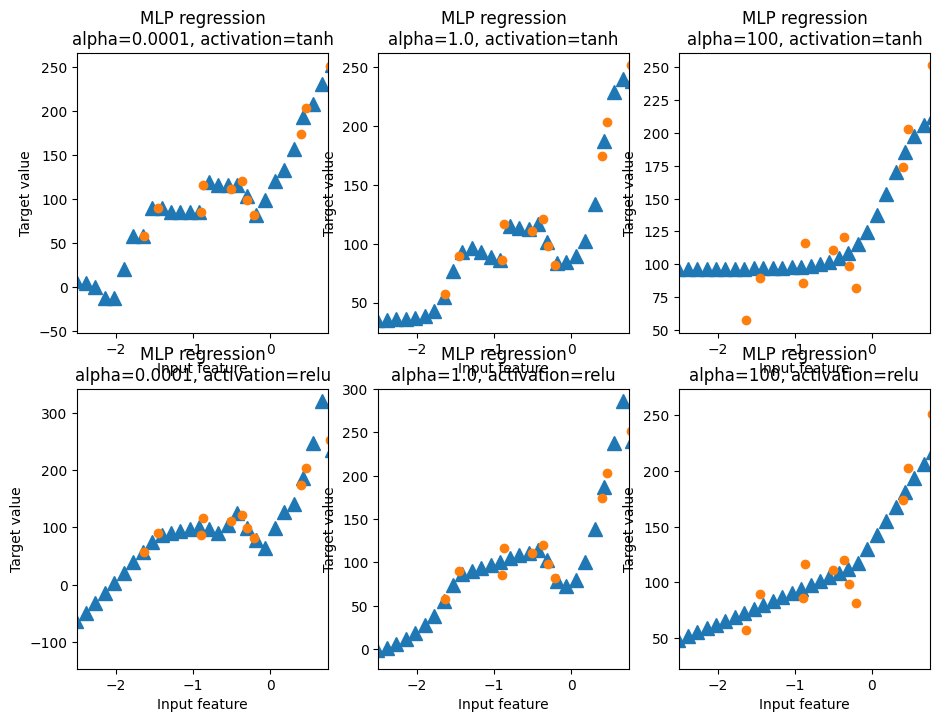

In [ ]:
from sklearn.neural_network import MLPRegressor

fig, subaxes = plt.subplots(2, 3, figsize=(11, 8))

X_predict_input = np.linspace(-3, 3, 50).reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X_R1[0::5], y_R1[0::5], random_state=0)

for thisaxisrow, thisactivation in zip(subaxes, ['tanh', 'relu']):
  for this_alpha, this_axis in zip([0.0001, 1.0, 100], thisaxisrow):
    mlpreg = MLPRegressor(hidden_layer_sizes=[100, 100],
                          max_iter=1000,
                          activation=thisactivation, alpha=this_alpha,
                          solver='lbfgs').fit(X_train, y_train)

    y_predict_output = mlpreg.predict(X_predict_input)
    this_axis.set_xlim([-2.5, 0.75])
    this_axis.plot(X_predict_input, y_predict_output,
                   '^',markersize=10)
    this_axis.plot(X_train, y_train, 'o')
    this_axis.set_xlabel('Input feature')
    this_axis.set_ylabel('Target value')
    this_axis.set_title(f'MLP regression\nalpha={this_alpha}, activation={thisactivation}')

## Neural Networks: Pros and Cons
### Pros:
- They form the basis for state-of-the-art models and can be formd into advanced architectures that effectively capture complex features given enough data and computation

### Cons:
- Larger, more complex models require significant training time, data and customization;
- Careful preprocessing of the data is needed;
- A good choice when the features are of similar types, but less so when features of very different types.

## Neural Nets: MLPClassifier and MLPRegressor Important parameters

- hidden_layer_sizes: sets the number of hidden layers and number of hidden units per layer;
- alpha: controls weight on the regularization penalty that shrinks weights to zero;
- activation: controls the nonlinear function used for the activation function, including 'relu', 'logistic' and 'tanh'.

# Deep Learning

## Summary

- Deep learning architectures combina a sophisticated automatic feature extraction phase with a supervised learning phase;
- The feature extraction phase uses a hierarchy of multiple feature extraction leayers;
- Starting from primitve, low-level features in the initial layer, each feature layer's output provides the input features to the next higher feature layer;
- All features are used in the final supervise larning model.

## Pros and Cons of Deep Learning
### Pros:
- Powerful: deep learning has achieved significatn gains over other machine learning approaches on many difficult learning tasks, leading to state-of-the-art performance across many different domains;
- Does effective automatic feature extraction, reducing the need for guesswork and heuristics on this key problem;
- Current software provides flexible architectures that can be adapted for new domains fairly easily.

### Cons:
- Can require huge amounts of training data;
- Can require huge amounts of computing power;
- Architectures can be complex and often must be highly tailored to a specific application;
- The resulting models may not be easily interpretable.


## Example stack: Deep Learning software for Python

### Higher level
- Keras https://keras.io/
- High-level APIs

### Lower level
- TensorFlow https://www.tensorflow.org/
- Core computation services (but also has higher-level APIs for high-performance models)

### Hardware level
- Libraries support high-performance computation via GPUs;
- Data structures: Numpy, SciPy. Computation: BLAS & Eigen (CPU) or CUDA & cuDNN (GPU)

## Popular deep learning frameworks
- Tensorflow;
- PyTorch;
- Keras

## Advantages of current high-level deep learning frameworks
- Simplicity
  - No need for feature engineering;
  - Pipelines built using only a few different vector/matrix/tensor operations.
- Scalability
  - Highly amenable to parallelization on GPUs or TPUs;
  - Trained by iterating over small batches of data: can handle datasets of arbitrary size.
- Versatility and Reusability
  - Can be trained on additional data without starting from scratch;
  - Can pretrain a model in one domain (e.g. image classification) and adjust its training for a different problem (e.g. video segamentation)

In [ ]:
import keras
from keras.utils import to_categorical

# 1. Data Preparation
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape(10000, 28*28)
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [ ]:
# 2. Model Definition
network = keras.models.Sequential()
network.add(keras.layers.Dense(512, activation='relu', input_shape=(28*28,)))
network.add(keras.layers.Dense(10, activation='softmax'))

network.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

In [ ]:
# 3. Model training
network.fit(train_images, train_labels, epochs=5, batch_size=128)

# 4. Model evaluation
test_loss, test_acc = network.evaluate(test_images, test_labels)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8754 - loss: 0.4316
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9661 - loss: 0.1158
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9790 - loss: 0.0703
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9842 - loss: 0.0513
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9892 - loss: 0.0368
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9739 - loss: 0.0812


# Data Leakage
- When the data you're using to train contains information about what you're trying to predict;
- Introducing information about the target during training that would not legitimately be available during actual use;
- Obvious examples:
  - Including the label to be predicted as a feature;
  - Including test data with training data.
- If your model performance is too good to be true, it probably is and likely due to "giveaway" features.

## More Subtle Examples of Data Leakage
- Prediction target: will user stay on a site, or leave?
  - Giveaway feature: total session length, based on information about future page visits.
- Predicting if a user on a financial site is likely to open an account:
  - An account number field that's only filled in once the user does open an account.
- Diagnostic test to predict a medical condition:
  - The existing patient dataset contains a binary variable that happens to mark wheter they had surgery for that condition;
  - Combinations of missing diagnosis codes that are not to be avaible while the patient's condition was still being studied;
  - The patient ID could contain information about specific diagnosis paths (e.g. for routine visit vs specialist).

# Other Examples of Data Leakage
- Leakage during training data:
  - Performing data preprocessing using parameters or results from analyzing the entire dataset: Normalization and rescaling, detecting and removing outliers, estimating missing values, feature selection;
  - Time-series datasets: using records from the future when computing features for the current prediction;
  - Errors in data values/gathering or missing variable indicatiors (e.g. the special value 999) can encode information about missing data that reveals information about the future.

- Leakage in features:
  - Removing variables that are not legitimate without also removing variables that encode the same or related information (e.g. diagnosis infor may still exist in patient ID);
  - Reversing of intentional rendomization or anonymization that reveals specific information about e.g. users not legitimately available in actual use.

# Detecting Data Leakage
- Before building the model:
  - Exploratory data analysis to find surprises in the data;
  - Are there features very highly correlated with the target value?
- After building the model:
  - Look for surprising feature behavior in the fitted model;
  - Are there features with very high weights or high information gain?
  - Simple rule-based models like decision trees can help with features like account numbers, patient IDs;
  - Is overall model performance surprisingly good compare to know results on the same dataset, or for similar problems on similar datasets?
- Limited real-world deployment of the trained model:
  - Potentially expensive in terms of development time, but more realistic;
  - Is the trained model generalizing well to new data?

## Minimizing Data Leakage
- Perform data preparation withini each cross-validation fold separately:
  - Scale/normalize data, perform feature selection, etc. Within each fold separately, not using the entire dataset;
  - For any such parameters estimated on the training data, you must use those same parameters to prepare data on the corresponding held-out test fold.
- With time seires data, use a timestamp cutoff
  - The cutoff value is set to the specific time point where prediction is to occur using current and past records;
  - Using a cutoff time will make sure you aren't accessing any data records that were gathered after the prediction time, i.e. in the future.
- Before any work with a new dataset, split off a final test validation dataset:
  - ... if you have enough data;
  - Use this final test dataset as the very last step in your validation;
  - Helps to check the true generalization performance of any trained models.